In [1]:
from Stocketal2008 import model, model_setup_bifurcation, model_setup_fsolve, model_setup

In [5]:
input_pars = {'Nutrient__value_init':1.29192474,
                'Phytoplankton__biomass_init':[0.44666332, 0.3404672, 0.91985636],
              'Zooplankton__biomass_init':[0.17493329, 1.07698726, 0.73048563, 1.3544284],
    'GGE__gge':0.3705050505050505,'HigherOrderMortality__rate': [0,0,0,0.026118181818181818]}

In [2]:
from stability_hooks import run_with_stability_analysis

# This automatically adds stability results to output.attrs
output = run_with_stability_analysis(model, model_setup)

# Access the results
if 'stability_analysis' in output.attrs:
    print(f"Stability: {output.attrs['stability_analysis']['stability']}")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[INFO] Initial state dimension: 8
[INFO] Initial state: [1.  1.5 1.5 1.5 0.1 0.1 0.1 0.1]
[WARNING] fsolve did not converge: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  Final state: [ 0.1078017   0.63728498  0.16514696  0.0258423  -0.00096568  0.22779862
  0.12510721  0.12584005]
  Residual norm: 1.49e-03
[WARNING] Skipping Jacobian computation due to convergence failure
------------------------------------------------------------
NUMERICAL STABILITY ANALYSIS RESULTS
------------------------------------------------------------
Steady State: [nan nan nan nan nan nan nan nan]
Convergence: Failed

Eigenvalues: Could not compute (converged=False)
------------------------------------------------------------
[HOOK] System stability: UNKNOWN
Stability: unknown


In [6]:
from stability_hooks import StabilityAnalysisHook

hook = StabilityAnalysisHook()

with model:
    output = model_setup.xsimlab.update_vars(input_vars=input_pars).xsimlab.run(hooks=[hook])

# Retrieve the results
stability_data = hook.get_results()
if stability_data:
    output.attrs['stability_analysis'] = stability_data
    print(f"System is {stability_data['stability']}")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[INFO] Initial state dimension: 8
[INFO] Initial state: [1.29192474 0.44666332 0.3404672  0.91985636 0.17493329 1.07698726
 0.73048563 1.3544284 ]
[INFO] Steady state found with residual norm: 1.26e-16
  Steady state: [1.29192474 0.44666332 0.3404672  0.91985636 0.17493329 1.07698726
 0.73048563 1.3544284 ]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 8 eigenvalues
------------------------------------------------------------
NUMERICAL STABILITY ANALYSIS RESULTS
------------------------------------------------------------
Steady State: [1.29192474 0.44666332 0.3404672  0.91985636 0.17493329 1.07698726
 0.73048563 1.3544284 ]
Convergence: Success

Eigenvalue Analysis:
  Number of eigenvalues: 8
  Max real part: -1.3709e-02
  Min real part: -4.6748e-01

Stability: STABLE (max real part: -1.3709e-02)
  Positive real parts: 0
  Negative real parts: 8
  Near-zero real parts: 0
  Complex eigenva

In [8]:
stability_data

{'converged': True,
 'steady_state': [1.2919247425907843,
  0.44666331775043205,
  0.34046719882519605,
  0.9198563577024449,
  0.17493328937057548,
  1.0769872586157105,
  0.7304856343757945,
  1.3544284024443514],
 'stability': 'stable',
 'max_eigenvalue_real': -0.013708907996906789,
 'min_eigenvalue_real': -0.4674752860430679,
 'eigenvalues_real': [-0.4674752860430679,
  -0.4674752860430679,
  -0.013708907996906789,
  -0.013708907996906789,
  -0.03190129544023969,
  -0.03190129544023969,
  -0.016696616776208005,
  -0.016696616776208005],
 'eigenvalues_imag': [0.42941661050262964,
  -0.42941661050262964,
  0.35016342148700996,
  -0.35016342148700996,
  0.0680717164938947,
  -0.0680717164938947,
  0.03401163739114577,
  -0.03401163739114577],
 'n_positive_eigenvalues': 0,
 'n_negative_eigenvalues': 8,
 'n_complex_pairs': 4}

In [7]:
from stability_hooks import capture_stability_metadata, get_stability_results

with model:
    output = model_setup.xsimlab.update_vars(input_vars=input_pars).xsimlab.run(hooks=[capture_stability_metadata])

# Retrieve the results
stability_data = get_stability_results()
if stability_data:
    output.attrs['stability_analysis'] = stability_data

[INFO] Initial state dimension: 8
[INFO] Initial state: [1.29192474 0.44666332 0.3404672  0.91985636 0.17493329 1.07698726
 0.73048563 1.3544284 ]
[INFO] Steady state found with residual norm: 1.26e-16
  Steady state: [1.29192474 0.44666332 0.3404672  0.91985636 0.17493329 1.07698726
 0.73048563 1.3544284 ]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 8 eigenvalues
------------------------------------------------------------
NUMERICAL STABILITY ANALYSIS RESULTS
------------------------------------------------------------
Steady State: [1.29192474 0.44666332 0.3404672  0.91985636 0.17493329 1.07698726
 0.73048563 1.3544284 ]
Convergence: Success

Eigenvalue Analysis:
  Number of eigenvalues: 8
  Max real part: -1.3709e-02
  Min real part: -4.6748e-01

Stability: STABLE (max real part: -1.3709e-02)
  Positive real parts: 0
  Negative real parts: 8
  Near-zero real parts: 0
  Complex eigenvalue pairs: 4
  Max oscillation frequency: 0.4294

  First 5 eigenvalues:
 

In [3]:
with model:
    model_output_ivp = model_setup.xsimlab.update_vars(input_vars=input_pars).xsimlab.run()
    
    # Retrieve from the solver instance
    stability_metadata = model.Core.core.solver.stability_results
    output.attrs['stability_analysis'] = stability_metadata

[INFO] Initial state dimension: 8
[INFO] Initial state: [1.29192474 0.44666332 0.3404672  0.91985636 0.17493329 1.07698726
 0.73048563 1.3544284 ]
[INFO] Steady state found with residual norm: 1.26e-16
  Steady state: [1.29192474 0.44666332 0.3404672  0.91985636 0.17493329 1.07698726
 0.73048563 1.3544284 ]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 8 eigenvalues


AttributeError: 'Model' object has no attribute 'Core'

In [ ]:
model_output_ivp

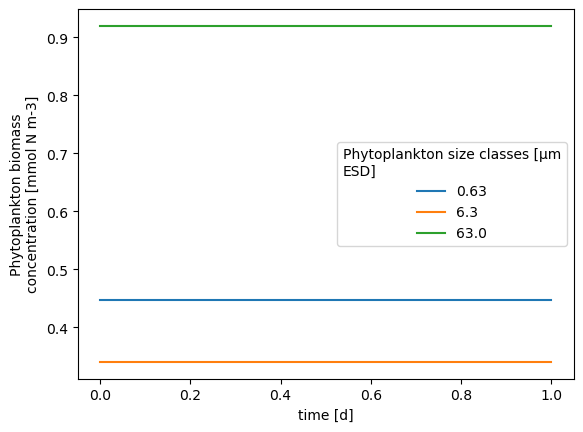

In [9]:
model_output_ivp.Phytoplankton__biomass.plot.line(x='time')

In [5]:
with model:
    model_output_fsolve = model_setup_fsolve.xsimlab.update_vars(input_vars=input_pars).xsimlab.run()

InitState [0.         1.29192474 0.44666332 0.3404672  0.91985636 0.17493329
 1.07698726 0.73048563 1.3544284 ]
[INFO] Steady state found with residual norm: 1.2643266404855218e-16
Residuals: [ 0.00000000e+00  1.11022302e-16  0.00000000e+00  5.55111512e-17
 -1.38777878e-17 -1.38777878e-17  0.00000000e+00 -1.38777878e-17
  0.00000000e+00]
YSTEADY [0.         1.29192474 0.44666332 0.3404672  0.91985636 0.17493329
 1.07698726 0.73048563 1.3544284 ]


In [6]:
with model:
    model_output = model_setup_bifurcation.xsimlab.update_vars(input_vars=input_pars).xsimlab.run()

[DEBUG] Computing Jacobian: 8 equations, 8 variables
[DEBUG] Sample equation 0: GGE_R*(Grazing_Imax_0*Grazing_phiPZ_0*P_0*Z_0*(Grazing_phiPZ_0**2*P_0**2/(Grazing_phiPZ_0**2*P_0**2 + Grazing_phiPZ_1**2*P_1**2 + Grazing_phiPZ_2**2*P_2**2 + Grazing_phiPZ_3**2*Z_0**2 + Grazing_phiPZ_
[DEBUG] Sample equation 1: -Grazing_Imax_0*Grazing_phiPZ_0*P_0*Z_0*(Grazing_phiPZ_0**2*P_0**2/(Grazing_phiPZ_0**2*P_0**2 + Grazing_phiPZ_1**2*P_1**2 + Grazing_phiPZ_2**2*P_2**2 + Grazing_phiPZ_3**2*Z_0**2 + Grazing_phiPZ_4**2*Z
[DEBUG] Jacobian computed, shape: (8, 8)
[DEBUG] Model too large, no attempt at Jacobian simplification...
[INFO] Will automatically use numerical Jacobian for eigenvalues if needed
[BifurcationSolver] Model assembled and lambdified successfully
[DEBUG] Initial state size: 8
[DEBUG] Initial state: [1.29192474, 0.44666332, 0.3404672, 0.91985636, 0.17493329, 1.07698726, 0.73048563, 1.3544284]
[DEBUG] Param values size: 70
[DEBUG] Param values: [0.0053, 1.0, 0.062, 0.45, 3.3, 1.0, 1.26, 0.

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [1]:
from my_xso_model_deriv import model_setup, model_setup_bifurcate, model as modelx

In [4]:
param_dict={
    'Nutrient__value_init':0.07779512531964816,
    'Phytoplankton__value_init':0.922204874680352,
}

with modelx:
    model_output = model_setup_bifurcate.xsimlab.update_vars(
            input_vars=param_dict
        ).xsimlab.run()


[DEBUG] Computing Jacobian: 2 equations, 2 variables
[DEBUG] Sample equation 0: -Growth_mu_max*N*P/(Growth_halfsat + N) + Inflow_rate*N0 - N*Outflow_rate
[DEBUG] Sample equation 1: Growth_mu_max*N*P/(Growth_halfsat + N) - Outflow_rate*P
[DEBUG] Jacobian computed, shape: (2, 2)
[DEBUG] Attempting Jacobian simplification...
[DEBUG] Jacobian simplified successfully
[BifurcationSolver] Model assembled and lambdified successfully
[DEBUG] Initial state size: 2
[DEBUG] Initial state: [0.07779512531964816, 0.922204874680352]
[DEBUG] Param values size: 6
[DEBUG] Param values: [1.0, 0.1, 0.1, 0.7, 1.0, 1.0]
[DEBUG] Testing RHS at initial state...
[DEBUG] RHS at initial state: [-1.85115443e-05  1.85115443e-05]
[DEBUG] RHS norm: 2.617927699180389e-05
[DEBUG] Testing Jacobian at initial state...
[DEBUG] Starting fsolve...
[DEBUG] Using analytical Jacobian...
[INFO] Steady state found!
  Steady state: [0.07777778 0.92222222]
  Residual norm: 7.806255641895632e-18
------------------------------------

In [5]:

with modelx:
    model_output = model_setup.xsimlab.update_vars(
            input_vars=param_dict
        ).xsimlab.run()

[INFO] Initial state dimension: 2
[INFO] Initial state: [0.07779513 0.92220487]
[INFO] Steady state found with residual norm: 4.43e-14
  Steady state: [0.07777778 0.92222222]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 2 eigenvalues
------------------------------------------------------------
NUMERICAL STABILITY ANALYSIS RESULTS
------------------------------------------------------------
Steady State: [0.07777778 0.92222222]
Convergence: Success

Eigenvalue Analysis:
  Number of eigenvalues: 2
  Max real part: -1.0000e-01
  Min real part: -1.0671e+00

Stability: STABLE (max real part: -1.0000e-01)
  Positive real parts: 0
  Negative real parts: 2
  Near-zero real parts: 0

  First 2 eigenvalues:
    λ_1 = -1.0671e+00
    λ_2 = -1.0000e-01
------------------------------------------------------------


In [3]:
model_output

<xarray.Dataset> Size: 304B
Dimensions:                     (time: 2, d: 2, clock: 2)
Coordinates:
  * clock                       (clock) int64 16B 0 1
  * time                        (time) float64 16B 0.0 1.0
Dimensions without coordinates: d
Data variables: (12/23)
    Core__solver_type           <U11 44B 'bifurcation'
    Growth__consumer            <U1 4B 'P'
    Growth__halfsat             float64 8B 0.7
    Growth__mu_max              int64 8B 1
    Growth__resource            <U1 4B 'N'
    Growth__uptake_value        (time) float64 16B 0.0 0.0
    ...                          ...
    Outflow__rate               float64 8B 0.1
    Outflow__var_list           (d) <U1 8B 'N' 'P'
    Phytoplankton__value        (time) float64 16B 0.9222 0.9222
    Phytoplankton__value_init   float64 8B 0.9222
    Phytoplankton__value_label  <U1 4B 'P'
    Time__time_input            (time) int64 16B 0 1

In [3]:
model_output

<xarray.Dataset> Size: 304B
Dimensions:                     (time: 2, d: 2, clock: 2)
Coordinates:
  * clock                       (clock) int64 16B 0 1
  * time                        (time) float64 16B 0.0 1.0
Dimensions without coordinates: d
Data variables: (12/23)
    Core__solver_type           <U11 44B 'bifurcation'
    Growth__consumer            <U1 4B 'P'
    Growth__halfsat             float64 8B 0.7
    Growth__mu_max              int64 8B 1
    Growth__resource            <U1 4B 'N'
    Growth__uptake_value        (time) float64 16B 0.0 0.0
    ...                          ...
    Outflow__rate               float64 8B 0.1
    Outflow__var_list           (d) <U1 8B 'N' 'P'
    Phytoplankton__value        (time) float64 16B 0.9222 0.9222
    Phytoplankton__value_init   float64 8B 0.9222
    Phytoplankton__value_label  <U1 4B 'P'
    Time__time_input            (time) int64 16B 0 1

In [2]:
import xso
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from my_xso_model import model, model_setup_ivp as model_setup

0.9221923666340226
0.07780763336597735


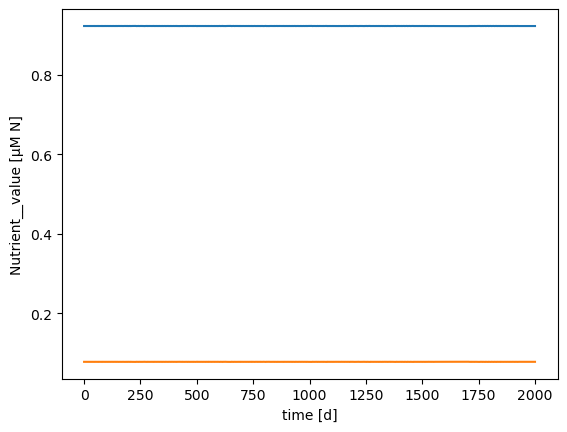

In [4]:
param_dict={
    'Nutrient__value_init':0.07779512531964816,
    'Phytoplankton__value_init':0.922204874680352,
}

with model:
    model_output = model_setup.xsimlab.update_vars(
            input_vars=param_dict
        ).xsimlab.run()
    
model_output.Phytoplankton__value.plot(x='time')

model_output.Nutrient__value.plot(x='time')
#print(model_output.Phytoplankton__value.isel(time=slice(1800.1999)).mean())

print(model_output.Phytoplankton__value.isel(time=slice(1800,1999)).mean().values)

print(model_output.Nutrient__value.isel(time=slice(1800,1999)).mean().values)

In [6]:
from my_xso_model import model, model_setup_deriv as model_setup

param_dict={
    'Nutrient__value_init':0.07779513,
    'Phytoplankton__value_init':0.922204874680352,
}

with model:
    model_output = model_setup.xsimlab.update_vars(
            input_vars=param_dict
        ).xsimlab.run()

ImportError: cannot import name 'model_setup_deriv' from 'my_xso_model' (/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/ParameterScans/my_xso_model.py)

In [2]:
from my_xso_model import model, model_setup_stability

param_dict={
    'Nutrient__value_init':0.07779513,
    'Phytoplankton__value_init':0.922204874680352,
}

with model:
    model_output = model_setup_stability.xsimlab.update_vars(
            input_vars=param_dict
        ).xsimlab.run()

[INFO] Initial state dimension: 2
[INFO] Initial state: [0.07779513 0.92220487]
[INFO] Steady state found with residual norm: 4.43e-14
  Steady state: [0.07777778 0.92222222]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 2 eigenvalues


In [3]:
model_output

<xarray.Dataset> Size: 296B
Dimensions:                     (time: 2, d: 2, clock: 2)
Coordinates:
  * clock                       (clock) int64 16B 0 1
  * time                        (time) float64 16B 0.0 1.0
Dimensions without coordinates: d
Data variables: (12/23)
    Core__solver_type           <U9 36B 'stability'
    Growth__consumer            <U1 4B 'P'
    Growth__halfsat             float64 8B 0.7
    Growth__mu_max              int64 8B 1
    Growth__resource            <U1 4B 'N'
    Growth__uptake_value        (time) float64 16B 0.0 0.0
    ...                          ...
    Outflow__rate               float64 8B 0.1
    Outflow__var_list           (d) <U1 8B 'N' 'P'
    Phytoplankton__value        (time) float64 16B 0.9222 0.9222
    Phytoplankton__value_init   float64 8B 0.9222
    Phytoplankton__value_label  <U1 4B 'P'
    Time__time_input            (time) int64 16B 0 1

In [4]:
from xso.parscans import run_xso_parscan

In [1]:
import numpy as np

from xso.parscans import run_xso_parscan

result_dataset = run_xso_parscan(
    model_file_name='my_xso_model',
    model_setup_name='model_setup_deriv',
    param_name='Nutrient__value_init',
    param_values=np.linspace(0.0001, 1.5, 20) ,
    param_name2='Phytoplankton__value_init',
    param_values2=np.linspace(0.0001, 1.5, 20) ,
    processes=20
)

# Display the result
if result_dataset is not None:
    print("\nFinal Scan Output Dataset:")
    print(result_dataset)

PROGRESS: Completed 20/20 outer points. (Nutrient__value_init = 1.5).

2D Scan complete. Total Time taken: 5.44902 seconds.

Final Scan Output Dataset:
<xarray.Dataset> Size: 93kB
Dimensions:                     (Phytoplankton__value_init: 20,
                                 Nutrient__value_init: 20, time: 2, d: 2,
                                 clock: 2)
Coordinates:
  * Nutrient__value_init        (Nutrient__value_init) float64 160B 0.0001 .....
  * Phytoplankton__value_init   (Phytoplankton__value_init) float64 160B 0.00...
  * clock                       (clock) int64 16B 0 1
  * time                        (time) float64 16B 0.0 0.0
Dimensions without coordinates: d
Data variables: (12/21)
    Core__solver_type           (Phytoplankton__value_init, Nutrient__value_init) <U5 8kB ...
    Growth__consumer            (Phytoplankton__value_init, Nutrient__value_init) <U1 2kB ...
    Growth__halfsat             (Phytoplankton__value_init, Nutrient__value_init) float64 3kB ...
    Gro

Plotting vector field and steady state...


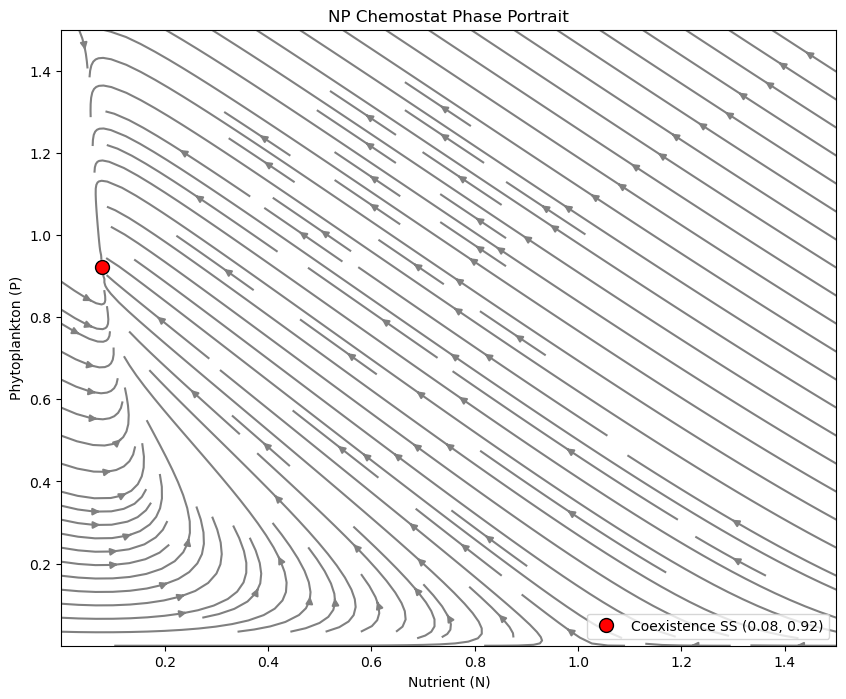

In [5]:
import matplotlib.pyplot as plt

# --- 1. Get Steady State (SS) Values ---
# (Assuming 'model_output' is the result from your FSolver run)
N_ss = model_output.Nutrient__value.isel(time=1).values
P_ss = model_output.Phytoplankton__value.isel(time=1).values

# --- 2. Extract Vector Field Data ---
# (Assuming 'result_dataset' is from your DerivativeCalculator scan)
N_axis = result_dataset['Nutrient__value_init']
P_axis = result_dataset['Phytoplankton__value_init']
dN_dt = result_dataset['Nutrient__value'].isel(time=1)
dP_dt = result_dataset['Phytoplankton__value'].isel(time=1)


# --- 3. Create the Plot ---

print("Plotting vector field and steady state...")
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot the streamplot (the vector field)
ax.streamplot(
    N_axis.values,    # x-coords
    P_axis.values,    # y-coords
    dN_dt.values,     # u (x-direction velocity)
    dP_dt.values,     # v (y-direction velocity)
    color='gray',
    density=1.5
)

# --- 4. ADD THE STEADY STATE ---
# Plot the coexistence steady state as a large, visible marker
ax.plot(
    N_ss, 
    P_ss, 
    'ro',  # 'r' = red, 'o' = circle marker
    markersize=10, 
    markeredgecolor='black', # Add a black edge for visibility
    label=f'Coexistence SS ({N_ss:.2f}, {P_ss:.2f})'
)


# --- 5. Format the Plot ---
ax.set_xlabel('Nutrient (N)')
ax.set_ylabel('Phytoplankton (P)')
ax.set_title('NP Chemostat Phase Portrait')
ax.set_xlim(N_axis.min(), N_axis.max())
ax.set_ylim(P_axis.min(), P_axis.max())
ax.legend() # Add a legend to label the points

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Get Steady State (SS) Values ---
# (Assuming 'model_output' is the result from your FSolver run)
N_ss = model_output.Nutrient__value.isel(time=1).values
P_ss = model_output.Phytoplankton__value.isel(time=1).values

# --- 2. Extract Vector Field Data ---
# (Assuming 'result_dataset' is from your DerivativeCalculator scan)
N_axis = result_dataset['Nutrient__value_init']
P_axis = result_dataset['Phytoplankton__value_init']
dN_dt = result_dataset['Nutrient__value'].isel(time=1)
dP_dt = result_dataset['Phytoplankton__value'].isel(time=1)


# --- 3. Create the Plot ---

print("Plotting vector field and steady state...")
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot the streamplot (the vector field)
ax.streamplot(
    N_axis.values,    # x-coords
    P_axis.values,    # y-coords
    dN_dt.values,     # u (x-direction velocity)
    dP_dt.values,     # v (y-direction velocity)
    color='gray',
    density=1.5
)

# --- 4. ADD THE STEADY STATE ---
# Plot the coexistence steady state as a large, visible marker
ax.plot(
    N_ss, 
    P_ss, 
    'ro',  # 'r' = red, 'o' = circle marker
    markersize=10, 
    markeredgecolor='black', # Add a black edge for visibility
    label=f'Coexistence SS ({N_ss:.2f}, {P_ss:.2f})'
)


# --- 5. Format the Plot ---
ax.set_xlabel('Nutrient (N)')
ax.set_ylabel('Phytoplankton (P)')
ax.set_title('NP Chemostat Phase Portrait')
ax.set_xlim(N_axis.min(), N_axis.max())
ax.set_ylim(P_axis.min(), P_axis.max())
ax.legend() # Add a legend to label the points

plt.show()

In [24]:
import numpy as np

from xso.parscans import run_xso_parscan

result_dataset = run_xso_parscan(
    model_file_name='my_xso_model_steadystate',
    param_name='Nutrient__value_init',
    param_values=np.linspace(0.0001, 1.5, 20) ,
    param_name2='Phytoplankton__value_init',
    param_values2=np.linspace(0.0001, 1.5, 20) ,
    processes=20
)

# Display the result
if result_dataset is not None:
    print("\nFinal Scan Output Dataset:")
    print(result_dataset)

PROGRESS: Completed 20/20 outer points. (Nutrient__value_init = 1.5).
InitState [0.00000000e+00 4.73752632e-01 1.00000000e-04]
[INFO] Steady state found with residual norm: 1.8382009115413966e-19
Residuals: [ 0.00000000e+00  0.00000000e+00 -1.83820091e-19]
YSTEADY [ 0.00000000e+00  1.00000000e+00 -3.76498982e-19]
InitState [0.         0.47375263 0.07904211]
[INFO] Steady state found with residual norm: 2.7914115103971132e-15
Residuals: [ 0.00000000e+00 -1.97064587e-15  1.97700103e-15]
YSTEADY [0.00000000e+00 1.00000000e+00 4.04927922e-15]
InitState [0.         0.47375263 0.15798421]
[INFO] Steady state found with residual norm: 1.6310379108530814e-18
Residuals: [0.00000000e+00 0.00000000e+00 1.63103791e-18]
YSTEADY [0.00000000e+00 1.00000000e+00 3.34068006e-18]
InitState [0.         0.47375263 0.23692632]
[INFO] Steady state found with residual norm: 1.0445876856256492e-15
Residuals: [ 0.00000000e+00 -7.35522754e-16  7.41734259e-16]
YSTEADY [0.00000000e+00 1.00000000e+00 1.51921475e-15

# FINAL CODE BELOW HERE

In [32]:
import numpy as np
from xso.parscans import run_xso_parscan
# Assuming your custom solvers are imported
# from custom_solvers import DerivativeCalculator, FSolver

# --- Scan 1: Get the Vector Field ---
# (Using the DerivativeCalculator you created)
print("Running vector field scan...")
vector_field_ds = run_xso_parscan(
    model_file_name='my_xso_model_deriv',
    param_name='Nutrient__value_init',
    param_values=np.linspace(0.0001, 1.5, 200), # Use the wider range
    param_name2='Phytoplankton__value_init',
    param_values2=np.linspace(0.0001, 1.5, 200), # Use the wider range
    processes=20
)

# --- Scan 2: Get the Converged Steady States ---
# (Using the default FSolver)
print("Running steady state scan...")
steady_state_ds = run_xso_parscan(
    model_file_name='my_xso_model_steadystate',
    param_name='Nutrient__value_init',
    param_values=np.linspace(0.0001, 1.5, 20),
    param_name2='Phytoplankton__value_init',
    param_values2=np.linspace(0.0001, 1.5, 20),
    processes=20
)

print("Scans complete. Plotting...")

PROGRESS: Completed 20/20 outer points. (Nutrient__value_init = 1.5).
InitState [0.00000000e+00 1.57984211e-01 1.00000000e-04]
[INFO] Steady state found with residual norm: 1.0307902652807634e-15
Residuals: [ 0.00000000e+00  7.35522754e-16 -7.22173698e-16]
YSTEADY [ 0.00000000e+00  1.00000000e+00 -1.47915095e-15]
InitState [0.         0.15798421 0.07904211]
[INFO] Steady state found with residual norm: 6.955732654007105e-17
Residuals: [ 0.00000000e+00  4.16333634e-17 -5.57214925e-17]
YSTEADY [ 0.00000000e+00  1.00000000e+00 -1.14128358e-16]
InitState [0.         0.15798421 0.15798421]
[INFO] Steady state found with residual norm: 1.5515838457795457e-17
Residuals: [ 0.00000000e+00 -6.93889390e-18  1.38777878e-17]
YSTEADY [0.         0.07777778 0.92222222]
InitState [0.         0.15798421 0.23692632]
[INFO] Steady state found with residual norm: 5.647850449853784e-17
Residuals: [ 0.00000000e+00 -3.81639165e-17  4.16333634e-17]
YSTEADY [0.         0.07777778 0.92222222]
InitState [0.     

Plotting...


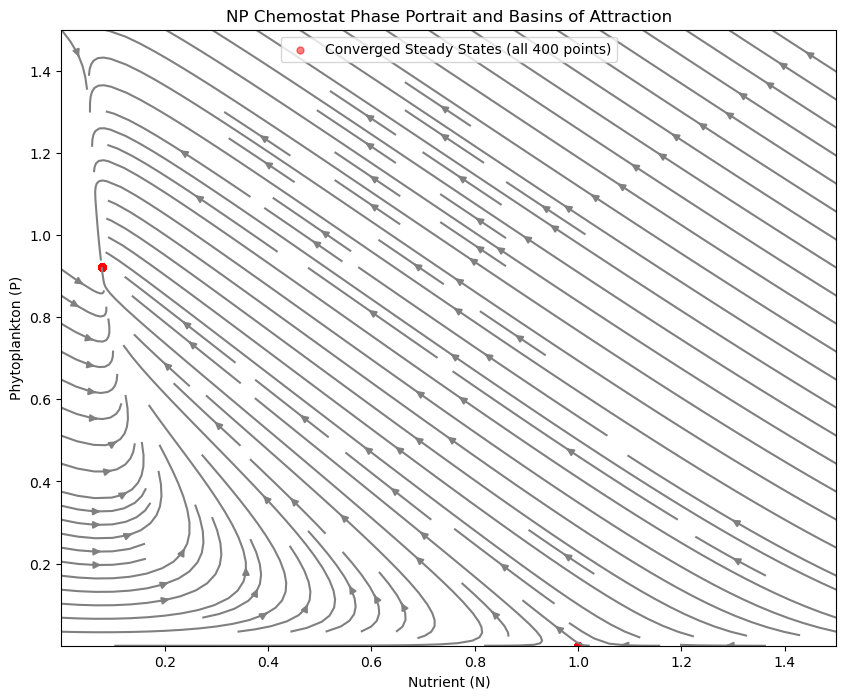

In [31]:
import matplotlib.pyplot as plt

# --- 1. Extract Vector Field Data ---
# (Using 'vector_field_ds' from Scan 1)
N_axis = vector_field_ds['Nutrient__value_init']
P_axis = vector_field_ds['Phytoplankton__value_init']
dN_dt = vector_field_ds['Nutrient__value'].isel(time=1)
dP_dt = vector_field_ds['Phytoplankton__value'].isel(time=1)

# --- 2. Extract ALL Steady State (SS) Data ---
# (Using 'steady_state_ds' from Scan 2)
# These are 2D arrays (shape 20x20)
N_ss_all = steady_state_ds['Nutrient__value'].isel(time=1)
P_ss_all = steady_state_ds['Phytoplankton__value'].isel(time=1)

# Flatten them into 1D arrays (of 400 points)
N_ss_flat = N_ss_all.values.flatten()
P_ss_flat = P_ss_all.values.flatten()

# --- 3. Create the Plot ---
print("Plotting...")
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot the streamplot (the vector field)
ax.streamplot(
    N_axis.values,    # x-coords
    P_axis.values,    # y-coords
    dN_dt.values,     # u (x-direction velocity)
    dP_dt.values,     # v (y-direction velocity)
    color='gray',
    density=1.5
)

# --- 4. Plot ALL the Converged Steady States ---
# Use scatter to show all 400 converged points
ax.scatter(
    N_ss_flat, 
    P_ss_flat, 
    color='red',
    marker='.',  # Use small dots
    s=100,        # Small size
    alpha=0.5,   # Make them semi-transparent
    label='Converged Steady States (all 400 points)'
)

# --- 5. Format the Plot ---
ax.set_xlabel('Nutrient (N)')
ax.set_ylabel('Phytoplankton (P)')
ax.set_title('NP Chemostat Phase Portrait and Basins of Attraction')
ax.set_xlim(N_axis.min(), N_axis.max())
ax.set_ylim(P_axis.min(), P_axis.max())
ax.legend()

plt.show()

Plotting vector field...


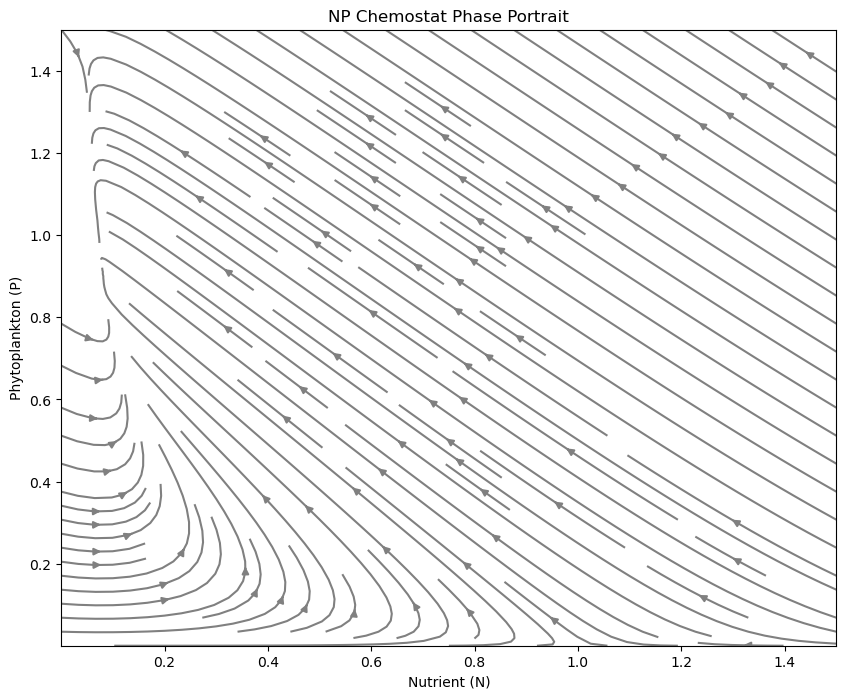

In [8]:
import matplotlib.pyplot as plt

# --- 1. Extract Data from your Dataset ---

# Get the 1D coordinate axes (your parameter scan ranges)
N_axis = result_dataset['Nutrient__value_init']
P_axis = result_dataset['Phytoplankton__value_init']

# Get the 2D derivative grids (the vector field)
# We select the second time step (index 1) which holds the derivatives
dN_dt = result_dataset['Nutrient__value'].isel(time=1)
dP_dt = result_dataset['Phytoplankton__value'].isel(time=1)


# --- 2. Create the Plot ---

print("Plotting vector field...")
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot the streamplot
# Pass the .values (NumPy arrays) to matplotlib
ax.streamplot(
    N_axis.values,    # x-coords
    P_axis.values,    # y-coords
    dN_dt.values,     # u (x-direction velocity)
    dP_dt.values,     # v (y-direction velocity)
    color='gray',
    density=1.5
)

# --- 3. Format the Plot ---
ax.set_xlabel('Nutrient (N)')
ax.set_ylabel('Phytoplankton (P)')
ax.set_title('NP Chemostat Phase Portrait')

# Set limits to match your scan range
ax.set_xlim(N_axis.min(), N_axis.max())
ax.set_ylim(P_axis.min(), P_axis.max())

plt.show()

<xarray.DataArray 'Nutrient__value_init' (Nutrient__value_init: 50)> Size: 400B
array([0.005   , 0.015102, 0.025204, 0.035306, 0.045408, 0.05551 , 0.065612,
       0.075714, 0.085816, 0.095918, 0.10602 , 0.116122, 0.126224, 0.136327,
       0.146429, 0.156531, 0.166633, 0.176735, 0.186837, 0.196939, 0.207041,
       0.217143, 0.227245, 0.237347, 0.247449, 0.257551, 0.267653, 0.277755,
       0.287857, 0.297959, 0.308061, 0.318163, 0.328265, 0.338367, 0.348469,
       0.358571, 0.368673, 0.378776, 0.388878, 0.39898 , 0.409082, 0.419184,
       0.429286, 0.439388, 0.44949 , 0.459592, 0.469694, 0.479796, 0.489898,
       0.5     ])
Coordinates:
  * Nutrient__value_init  (Nutrient__value_init) float64 400B 0.005 ... 0.5